# Automatiseringsbeslut: en riskjusterad kalkyl

Det här är en modell jag byggt för att slippa gissa oss fram till om något är värt
att automatisera. Frågan dyker upp hela tiden: någon har en manuell rutin, den känns
tjatig, och magkänslan säger att vi borde bygga bort den. Problemet är att magkänslan
nästan alltid räknar fel. Den utgår från att bygget tar exakt så lång tid man gissade,
att automationen funkar felfritt, och att processen lever för evigt. Inget av det
stämmer i verkligheten.

Så istället för "sparad tid är större än byggtid, alltså kör" svarar modellen på något
mer användbart: hur sannolikt är det att vi faktiskt tjänar på det, hur mycket i snitt,
och hur mycket riskerar vi om det går snett. Allt i kronor, för det är så beslutet
fattas i slutändan.

## Varför magkänslan ljuger

Tre antaganden som alltid slår fel, och som modellen därför bakar in:

1. **Bygget tar exakt så lång tid du gissade.** Det gör det aldrig. Utvecklingsestimat
   lutar systematiskt mot underskattning. Det är väl dokumenterat i forskningen, framför
   allt hos Magne Jørgensen, som visar att själva sättet vi vanligtvis mäter
   estimeringsfel på till och med belönar den som gissar för lågt. Därför utgår modellen
   från gissningen som median men låter den kunna bli rejält mycket värre, inte
   symmetriskt åt båda håll.
2. **Automationen funkar perfekt.** Den gör fel ibland, och den kanske aldrig ens når
   produktion.
3. **Processen lever för evigt.** I regel dör den strax efter go-live, eller byts ut när
   något annat ändras.

## De tre stegen

### 1. Deterministisk kalkyl
Sparade timmar minus underhåll minus byggtid, men justerat för tre saker som brukar
glömmas: att framtida tid är mindre värd än tid idag (diskontering), att processen kan dö
innan horisonten är slut (överlevnad), och att bygget kanske aldrig når produktion. Sedan
översätts allt till kronor.

### 2. Monte Carlo
Ett enda svar döljer risken, så jag låter de osäkra siffrorna variera slumpmässigt över
50 000 scenarier. Byggtiden kan bli lite kortare men explodera uppåt, manuell tid och
tillförlitlighet pendlar, och i en del scenarier havererar hela bygget. Ut kommer en
fördelning istället för en punkt, vilket gör att jag kan säga "88 procent chans att det
lönar sig" istället för att låtsas veta exakt. Det här är standard inom
investeringsbedömning. Poängen är att man slutar fråga "vad blir resultatet" och börjar
fråga "vad är intervallet av möjliga resultat och hur sannolikt är vart och ett".

### 3. Känslighetsanalys
Knuffar varje parameter upp och ner och ser vilken som rör resultatet mest. Om domen
vänder på en liten ändring i byggtid vet man var den verkliga osäkerheten sitter, och vad
som är värt att gräva i innan man bestämmer sig.

## Två saker som gör kalkylen ärlig

Det här är där de flesta ROI-mallar fuskar, medvetet eller inte.

**Sparad tid blir inte automatiskt pengar.** Om ingen använder den frigjorda tiden till
något som faktiskt skapar värde är besparingen mest luft. Därför räknar modellen bara en
andel av tiden som riktigt värde (`capacity_realization`, här 70 procent). Att det behövs
har det räknats på: en Deloitte-studie av 1200 företag fann att de som körde rak ROI
överskattade avkastningen med någonstans mellan 38 och 52 procent. Det är i den
storleksordningen mina haircuts drar ner kalkylen.

**Byggtimmen prissätts separat från den sparade timmen.** Om en dyr specialist ersätter en
billig process blir kalkylen sämre än den ser ut. I vårt fall tjänar en utvecklare och en
controller ungefär lika, runt 55 000 i månaden, så här blir timpriset detsamma på båda
sidor. Men modellen håller isär dem: sätt `builder_monthly_salary_sek` till en annan lön
så prissätts bygg- och underhållstimmen efter den, medan den sparade timmen fortsätter
värderas efter `monthly_salary_sek`. Underhållet följer byggarens timpris, inte
verksamhetens, eftersom det är utvecklaren som gör det.

Själva idén att sätta kronor på sådant som känns svårmätt kommer från Douglas Hubbards
arbete, boken How to Measure Anything och metoden Applied Information Economics. Han
kombinerar kalibrerade uppskattningar, Monte Carlo och lite Bayesiansk statistik, och tar
uttryckligen upp teknik-ROI och teknikrisk som exempel. Det är i praktiken ryggraden i den
här modellen.

## Så räknas timpriset (från 55 000 kr/mån)

Timpriset gissas inte, det härleds från månadslönen. Det är fullt belastat, alltså lön plus
arbetsgivaravgift plus overhead, fördelat på faktiska arbetstimmar (inte 2 080, för ingen
jobbar 2 080 debiterbara timmar på ett år):

| Steg | Belopp |
|---|---|
| Månadslön | 55 000 kr |
| Årslön (×12) | 660 000 kr |
| + arbetsgivaravgift (31,42%) | 867 000 kr |
| + overhead (pension, semester, lokaler, IT ~35%) | 1 171 000 kr |
| ÷ effektiva timmar/år (~1 702 h) | **≈ 690 kr/h** |

Vill man räkna snålare sätter man `overhead_pct = 0.0`, då blir det bara lön plus
arbetsgivaravgift, ungefär **510 kr/h**.

## Siffrorna i exempel-caset

### Ingångsvärden för besparingen
| Parameter | Värde | Vad den betyder |
|---|---|---|
| `manual_minutes_per_run` | 90 min | Manuell tid per körning |
| `runs_per_year` | 52 | Antal körningar per år (varje vecka) |
| `horizon_years` | 3,0 år | Hur länge processen antas leva |
| `monthly_salary_sek` | 55 000 kr | Månadslön för den som gör jobbet idag (ger ~690 kr/h belastat) |
| `capacity_realization` | 0,70 | Andel sparad tid som faktiskt blir värde |

### Kostnadssidan
| Parameter | Värde | Vad den betyder |
|---|---|---|
| `build_hours` | 40 h | Byggtid |
| `maintenance_hours_per_year` | 8 h/år | Underhåll, samma timpris |
| `builder_monthly_salary_sek` | `None` | Byggarens lön; `None` = samma yrkesgrupp |
| (härlett) byggtimpris | 690 kr/h | Samma yrkesgrupp här, samma belastade timpris |

### Riskparametrar som skalar ner nyttan
| Parameter | Värde | Vad den betyder |
|---|---|---|
| `p_go_live` | 0,90 | 90% chans att bygget når prod |
| `reliability` | 0,95 | 95% av körningarna görs rätt |
| `obsolescence_hazard` | 0,10 | 10% risk per år att processen dör |
| `discount_rate` | 0,05 | 5% diskontering av framtida värde |

### Så blir det kronor
- Brutto sparad tid: 90 min × 52 × 3 år = **234 timmar**
- Byggkostnad: 40 h × 690 kr ≈ **27 500 kr**
- En sparad timme räknas inte som fulla 690 kr. Efter `capacity_realization` blir den
  värd 690 × 0,70 ≈ **483 kr** i modellen. Det är den siffran som faktiskt driver
  besparingen.

Efter alla haircuts (capacity, reliability, p_go_live, diskontering, överlevnad) landar
exempel-caset på ungefär:

| Nyckeltal | Värde |
|---|---|
| Riskjusterat nettovärde (deterministiskt) | ~32 800 kr |
| EMV (Monte Carlo) | ~33 200 kr |
| ROI | ~111% |
| Sannolikhet lönsam | 88% |
| Nedsida om det går fel (CVaR) | ~-26 200 kr |
| **Dom** | **STARK AUTOMATISERA** |

## Där modellen fortfarande förenklar

En ärlig brist: den drar alla osäkra parametrar oberoende av varandra. I verkligheten
hänger ett struligt bygge ihop med både mer underhåll och högre risk att det aldrig når
produktion. Det betyder att den verkliga nedsidan i svansen är något tjockare än vad
siffrorna visar. Bra att ha i bakhuvudet innan man lutar sig för hårt mot exakt hur illa
det kan gå.

## Vad du får ut
- **Sannolikhet lönsam:** hur ofta det går plus i simuleringarna.
- **EMV:** förväntat nettovärde i kronor, talet som går att jämföra mot andra investeringar.
- **ROI:** avkastning i förhållande till byggkostnaden.
- **Nedsida om det går fel (CVaR):** inte bara hur ofta, utan hur mycket vi förlorar när
  det faktiskt går snett.

De två siffror som flyttar utfallet mest är andelen realiserad kapacitet och
overhead-påslaget i timpriset, så det är dem man ska vara noga med.


  AUTOMATISERINGSBESLUT: RISKJUSTERAD KALKYL (v5, i kronor)
  Timpris (härlett från 55000 kr/mån): 688 kr/h

[ DETERMINISTISK ]
  timpris_sparad_timme_sek_per_h.......... 688
  timpris_byggtimme_sek_per_h............. 688
  naiv_bruttobesparing_h.................. 234.0
  riskjusterad_nettobesparing_h........... 92.2
  byggkostnad_sek......................... 27519
  riskjusterat_nettovarde_sek............. 32827
  roi_pct................................. 119.3
  breakeven_korningar..................... 47.4
  breakeven_manader....................... 10.9
  verdict_deterministisk.................. AUTOMATISERA

[ MONTE CARLO ]  (osäkerheten kvantifierad i kronor)
  sannolikhet_lonsam...................... 0.876
  sannolikhet_totalflopp.................. 0.101
  EMV_sek................................. 33174
  ROI_pct................................. 111.3
  netto_P5_sek_VaR........................ -28139
  netto_P10_sek........................... -14852
  netto_P50_sek.................

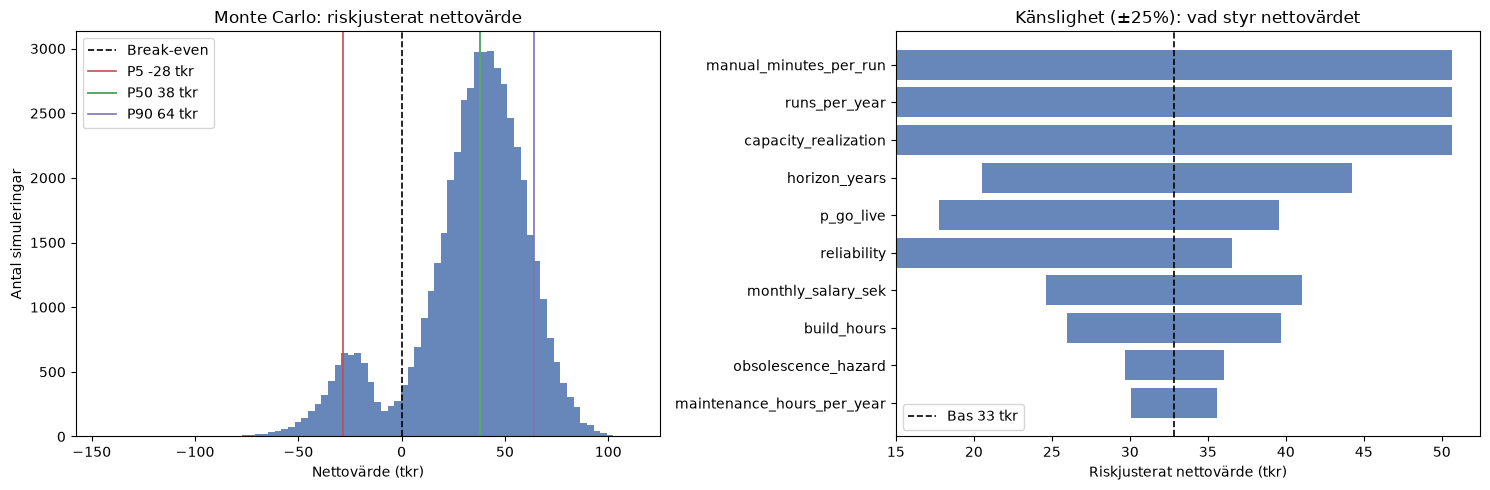

In [1]:
from dataclasses import dataclass, field
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------------
# Lönelogik. Härleder fullt belastad timkostnad från månadslön, transparent
# och justerbar, istället för att gissa en siffra.
# ---------------------------------------------------------------------------
def burdened_hourly_rate(monthly_salary_sek: float,
                         social_fee_pct: float = 0.3142,
                         overhead_pct: float = 0.35,
                         effective_hours_per_year: float = 1702.0) -> float:
    """
    Månadslön -> fullt belastad timkostnad.

      årslön          = månadslön * 12
      + arbetsgivaravgift (social_fee_pct, default 31.42%)
      + overhead      (pension, semester, lokaler, IT, adm; default 35%)
      / effektiva timmar (default 1702 = 2080 brutto minus semester,
                          helgdagar och sjuk/utbildning)

    Snål kalkyl: sätt overhead_pct=0.0 -> bara lön + arbetsgivaravgift (~510 kr/h).
    Full kalkyl: overhead_pct=0.35 -> ~690 kr/h vid 55k/mån.
    """
    annual = monthly_salary_sek * 12
    fully_loaded = annual * (1 + social_fee_pct) * (1 + overhead_pct)
    return fully_loaded / effective_hours_per_year


# ---------------------------------------------------------------------------
# Konfiguration. Var brutalt ärlig, annars räknar modellen fram exakt det
# svar du redan bestämt dig för.
# ---------------------------------------------------------------------------
@dataclass
class AutomationCase:
    # --- Manuellt arbete som ska ersättas ---
    manual_minutes_per_run: float           # ärlig tid för hand, per körning
    runs_per_year: float                    # 52 = varje vecka osv
    horizon_years: float = 3.0              # hur länge processen realistiskt lever

    # --- Bygg- och underhållskostnad (i timmar) ---
    build_hours: float = 40.0
    maintenance_hours_per_year: float = 8.0

    # --- Lön: HÄR sätts timpriset (härleds, gissas inte) ---
    monthly_salary_sek: float = 55000.0     # den som gör jobbet manuellt idag
    builder_monthly_salary_sek: float | None = None  # None = samma yrkesgrupp
    social_fee_pct: float = 0.3142          # arbetsgivaravgift
    overhead_pct: float = 0.35              # pension, semester, lokaler, IT, adm
    effective_hours_per_year: float = 1702.0  # debiterbara timmar, inte 2080

    # --- Risk ---
    p_go_live: float = 0.90                 # chans att bygget blir klart OCH når prod
    reliability: float = 0.95               # andel körningar roboten klarar rätt
    obsolescence_hazard: float = 0.10       # årlig risk att processen dör/byts ut
    discount_rate: float = 0.05             # tidsvärde på framtida kronor

    # --- Pengar ---
    capacity_realization: float = 0.70      # andel sparad tid som FAKTISKT blir värde

    # --- Härledda timpriser (fylls i __post_init__) ---
    hourly_value_sek: float = field(init=False)      # värdet av en sparad timme
    build_hourly_cost_sek: float = field(init=False) # bygg- och underhållstimmen

    # --- Monte Carlo-antaganden (tidigare gömda magiska tal) ---
    build_sigma: float = 0.4                # lognormal spridning byggtid, fet svans uppåt
    manual_low_frac: float = 0.70           # triangel vänster på manuell tid
    manual_high_frac: float = 1.40          # triangel höger
    reliability_conf: float = 40.0          # högre = mer säker på reliability
    maint_gamma_shape: float = 4.0          # underhållets gamma-form (kan bara bli värre)
    hazard_conf: float = 30.0               # beta-conf för osäker obsolescence_hazard

    def _recompute_rates(self) -> None:
        """
        Härled timpriserna från lönerna. Anropas vid skapande och varje gång en
        löneparameter ändras (t.ex. i känslighetsanalysen).

        Två sidor hålls isär: den sparade timmen prissätts efter den som gör
        jobbet manuellt idag, bygg- och underhållstimmen efter den som bygger.
        Lämnar man builder_monthly_salary_sek som None antas samma yrkesgrupp
        och båda blir identiska.
        """
        self.hourly_value_sek = burdened_hourly_rate(
            self.monthly_salary_sek, self.social_fee_pct,
            self.overhead_pct, self.effective_hours_per_year)
        builder_salary = (self.monthly_salary_sek
                         if self.builder_monthly_salary_sek is None
                         else self.builder_monthly_salary_sek)
        self.build_hourly_cost_sek = burdened_hourly_rate(
            builder_salary, self.social_fee_pct,
            self.overhead_pct, self.effective_hours_per_year)

    def __post_init__(self):
        self._recompute_rates()

    def validate(self) -> None:
        """Fånga uppenbara inmatningsfel innan de blir tysta konstigheter."""
        if self.manual_minutes_per_run <= 0:
            raise ValueError("manual_minutes_per_run måste vara > 0")
        if self.runs_per_year <= 0:
            raise ValueError("runs_per_year måste vara > 0")
        if self.horizon_years <= 0:
            raise ValueError("horizon_years måste vara > 0")
        if self.build_hours <= 0:
            raise ValueError("build_hours måste vara > 0 (lognormal byggtid)")
        if self.maintenance_hours_per_year < 0:
            raise ValueError("maintenance_hours_per_year kan inte vara negativ")
        for name in ("p_go_live", "reliability", "obsolescence_hazard",
                     "capacity_realization"):
            v = getattr(self, name)
            if not 0.0 <= v <= 1.0:
                raise ValueError(f"{name} måste ligga i [0,1], fick {v}")


# ---------------------------------------------------------------------------
# Hjälpare
# ---------------------------------------------------------------------------
def _year_chunks(horizon_years):
    """(fraction, t_slut) per (del)år. Delåret får fraktionellt slut-t."""
    full = int(np.floor(horizon_years))
    remainder = horizon_years - full
    chunks = [(1.0, t) for t in range(1, full + 1)]
    if remainder > 0:
        chunks.append((remainder, full + remainder))
    return chunks


def _clamp01(x):
    return min(max(x, 0.0), 1.0)


def _beta_from_mean(mean, conf, rng, size):
    mean = min(max(mean, 1e-6), 1 - 1e-6)
    return rng.beta(mean * conf, (1 - mean) * conf, size=size)


def hours_to_value_sek(saved_hours, case: "AutomationCase"):
    """Sparade timmar -> kronor, med capacity_realization-haircut."""
    return saved_hours * case.capacity_realization * case.hourly_value_sek


# ---------------------------------------------------------------------------
# Deterministisk kalkyl. Ett svar, inga sannolikheter. I både timmar OCH kr.
# ---------------------------------------------------------------------------
def deterministic_analysis(case: AutomationCase) -> dict:
    case.validate()
    annual_manual_hours = case.manual_minutes_per_run / 60.0 * case.runs_per_year
    naive_gross_saved_h = annual_manual_hours * case.horizon_years

    gross_saved_h = 0.0
    maint_h = 0.0
    for frac, t in _year_chunks(case.horizon_years):
        weight = ((1 - case.obsolescence_hazard) ** t) / ((1 + case.discount_rate) ** t)
        gross_saved_h += annual_manual_hours * case.reliability * frac * weight
        maint_h += case.maintenance_hours_per_year * frac * weight
    gross_saved_h *= case.p_go_live
    maint_h *= case.p_go_live

    risk_adjusted_net_h = gross_saved_h - maint_h - case.build_hours

    value_sek = hours_to_value_sek(gross_saved_h, case)
    maint_sek = maint_h * case.build_hourly_cost_sek   # underhåll = byggarens timme
    build_sek = case.build_hours * case.build_hourly_cost_sek
    net_sek = value_sek - maint_sek - build_sek
    roi_pct = (net_sek / build_sek * 100) if build_sek else np.inf

    value_per_run_sek = (case.manual_minutes_per_run / 60.0 * case.reliability
                         * case.capacity_realization * case.hourly_value_sek)
    maint_per_run_sek = (case.maintenance_hours_per_year / case.runs_per_year
                         * case.build_hourly_cost_sek)
    net_per_run_sek = value_per_run_sek - maint_per_run_sek
    if net_per_run_sek > 0:
        breakeven_runs = build_sek / net_per_run_sek
        breakeven_months = breakeven_runs / (case.runs_per_year / 12.0)
    else:
        breakeven_runs = np.inf
        breakeven_months = np.inf

    return {
        "timpris_sparad_timme_sek_per_h": round(case.hourly_value_sek),
        "timpris_byggtimme_sek_per_h": round(case.build_hourly_cost_sek),
        "naiv_bruttobesparing_h": round(naive_gross_saved_h, 1),
        "riskjusterad_nettobesparing_h": round(risk_adjusted_net_h, 1),
        "byggkostnad_sek": round(build_sek),
        "riskjusterat_nettovarde_sek": round(net_sek),
        "roi_pct": round(roi_pct, 1) if np.isfinite(roi_pct) else "oändlig",
        "breakeven_korningar": (round(breakeven_runs, 1)
                                if np.isfinite(breakeven_runs) else "aldrig"),
        "breakeven_manader": (round(breakeven_months, 1)
                              if np.isfinite(breakeven_months) else "aldrig"),
        "verdict_deterministisk": ("AUTOMATISERA" if net_sek > 0
                                   else "LÅT BLI (räknar hem sig inte)"),
    }


# ---------------------------------------------------------------------------
# Monte Carlo. Fördelningen i kronor. Returnerar sammanfattning + net_sek.
# ---------------------------------------------------------------------------
def monte_carlo(case: AutomationCase, n_sims: int = 50_000, seed: int = 42):
    case.validate()
    rng = np.random.default_rng(seed)

    build_h = rng.lognormal(mean=np.log(case.build_hours),
                            sigma=case.build_sigma, size=n_sims)
    manual = rng.triangular(
        left=case.manual_minutes_per_run * case.manual_low_frac,
        mode=case.manual_minutes_per_run,
        right=case.manual_minutes_per_run * case.manual_high_frac,
        size=n_sims,
    )
    reliability = _beta_from_mean(case.reliability, case.reliability_conf, rng, n_sims)
    maint = rng.gamma(shape=case.maint_gamma_shape,
                      scale=case.maintenance_hours_per_year / case.maint_gamma_shape,
                      size=n_sims)
    hazard = _beta_from_mean(case.obsolescence_hazard, case.hazard_conf, rng, n_sims)

    annual_manual_hours = manual / 60.0 * case.runs_per_year
    gross_saved_h = np.zeros(n_sims)
    maint_h = np.zeros(n_sims)
    for frac, t in _year_chunks(case.horizon_years):
        weight = ((1 - hazard) ** t) / ((1 + case.discount_rate) ** t)
        gross_saved_h += annual_manual_hours * reliability * frac * weight
        maint_h += maint * frac * weight

    went_live = rng.random(n_sims) < case.p_go_live
    gross_saved_h = np.where(went_live, gross_saved_h, 0.0)
    maint_h = np.where(went_live, maint_h, 0.0)

    value_sek = hours_to_value_sek(gross_saved_h, case)
    maint_sek = maint_h * case.build_hourly_cost_sek   # underhåll = byggarens timme
    build_sek = build_h * case.build_hourly_cost_sek
    net_sek = value_sek - maint_sek - build_sek

    p_profitable = float(np.mean(net_sek > 0))
    p_total_flop = float(np.mean(~went_live))
    downside = net_sek[net_sek < 0]
    cvar_sek = float(downside.mean()) if downside.size else 0.0
    emv_sek = float(net_sek.mean())
    roi_pct = emv_sek / float(build_sek.mean()) * 100
    p5, p10, p50, p90 = np.percentile(net_sek, [5, 10, 50, 90])

    summary = {
        "sannolikhet_lonsam": round(p_profitable, 3),
        "sannolikhet_totalflopp": round(p_total_flop, 3),
        "EMV_sek": round(emv_sek),
        "ROI_pct": round(roi_pct, 1),
        "netto_P5_sek_VaR": round(float(p5)),
        "netto_P10_sek": round(float(p10)),
        "netto_P50_sek": round(float(p50)),
        "netto_P90_sek": round(float(p90)),
        "forvantad_forlust_om_fel_sek": round(cvar_sek),
        "verdict_montecarlo": (
            "STARK AUTOMATISERA" if p_profitable > 0.85 else
            "AUTOMATISERA (men med marginal)" if p_profitable > 0.70 else
            "TVEKSAMT (för mycket nedsida)" if p_profitable > 0.50 else
            "LÅT BLI (mer sannolikt förlust)"
        ),
    }
    return summary, net_sek


# ---------------------------------------------------------------------------
# Känslighetsanalys.
# ---------------------------------------------------------------------------
def sensitivity(case: AutomationCase, pct: float = 0.25) -> pd.DataFrame:
    prob_params = {"p_go_live", "reliability", "obsolescence_hazard",
                   "capacity_realization"}
    # OBS: hourly_value/build_cost är härledda, så vi knuffar månadslönen istället.
    params = [
        "manual_minutes_per_run", "runs_per_year", "horizon_years",
        "build_hours", "maintenance_hours_per_year",
        "p_go_live", "reliability", "obsolescence_hazard",
        "capacity_realization", "monthly_salary_sek",
    ]
    if case.builder_monthly_salary_sek is not None:
        params.append("builder_monthly_salary_sek")

    def adjust(name, value):
        return _clamp01(value) if name in prob_params else value

    rows = []
    for p in params:
        original = getattr(case, p)
        try:
            setattr(case, p, adjust(p, original * (1 - pct)))
            case._recompute_rates()   # räkna om timpris om lönen ändrades
            low = deterministic_analysis(case)["riskjusterat_nettovarde_sek"]
            setattr(case, p, adjust(p, original * (1 + pct)))
            case._recompute_rates()
            high = deterministic_analysis(case)["riskjusterat_nettovarde_sek"]
        finally:
            setattr(case, p, original)
            case._recompute_rates()
        rows.append({
            "parameter": p,
            f"netto_vid_-{pct:.0%}_sek": low,
            f"netto_vid_+{pct:.0%}_sek": high,
            "spann_sek": round(abs(high - low)),
        })

    return (pd.DataFrame(rows)
            .sort_values("spann_sek", ascending=False)
            .reset_index(drop=True))


# ---------------------------------------------------------------------------
# Plottar. Lazy matplotlib-import så att räkningen kör även utan paketet.
# ---------------------------------------------------------------------------
def plot_distribution(net_sek: np.ndarray, case: AutomationCase, ax=None):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib saknas, hoppar över histogram.")
        return None
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4.5))
    p5, p50, p90 = np.percentile(net_sek, [5, 50, 90])
    ax.hist(net_sek / 1000, bins=80, color="#4C72B0", alpha=0.85)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--", label="Break-even")
    ax.axvline(p5 / 1000, color="#C44E52", linewidth=1.2, label=f"P5 {p5/1000:.0f} tkr")
    ax.axvline(p50 / 1000, color="#55A868", linewidth=1.4, label=f"P50 {p50/1000:.0f} tkr")
    ax.axvline(p90 / 1000, color="#8172B3", linewidth=1.2, label=f"P90 {p90/1000:.0f} tkr")
    ax.set_title("Monte Carlo: riskjusterat nettovärde")
    ax.set_xlabel("Nettovärde (tkr)")
    ax.set_ylabel("Antal simuleringar")
    ax.legend()
    return ax


def plot_tornado(sens_df: pd.DataFrame, case: AutomationCase, ax=None):
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("matplotlib saknas, hoppar över tornado.")
        return None
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 4.5))
    base = deterministic_analysis(case)["riskjusterat_nettovarde_sek"]
    low_col = [c for c in sens_df.columns if c.startswith("netto_vid_-")][0]
    high_col = [c for c in sens_df.columns if c.startswith("netto_vid_+")][0]
    df = sens_df.sort_values("spann_sek", ascending=True).reset_index(drop=True)
    for i, row in df.iterrows():
        lo, hi = sorted([row[low_col], row[high_col]])
        ax.barh([i], [(hi - lo) / 1000], left=[lo / 1000], color="#4C72B0", alpha=0.85)
    ax.axvline(base / 1000, color="black", linewidth=1.2, linestyle="--",
               label=f"Bas {base/1000:.0f} tkr")
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["parameter"])
    ax.set_title("Känslighet (±25%): vad styr nettovärdet")
    ax.set_xlabel("Riskjusterat nettovärde (tkr)")
    ax.legend()
    return ax


# ---------------------------------------------------------------------------
# Rapport.
# ---------------------------------------------------------------------------
def full_report(case: AutomationCase, n_sims: int = 50_000, seed: int = 42,
                show_plots: bool = False, save_path: str | None = None) -> dict:
    det = deterministic_analysis(case)
    mc, net_sek = monte_carlo(case, n_sims=n_sims, seed=seed)
    sens = sensitivity(case)

    print("=" * 62)
    print("  AUTOMATISERINGSBESLUT: RISKJUSTERAD KALKYL (v5, i kronor)")
    print("=" * 62)
    print(f"  Timpris (härlett från {case.monthly_salary_sek:.0f} kr/mån): "
          f"{case.hourly_value_sek:.0f} kr/h")
    if round(case.build_hourly_cost_sek) != round(case.hourly_value_sek):
        print(f"  Byggtimme (annan yrkesgrupp): "
              f"{case.build_hourly_cost_sek:.0f} kr/h")

    print("\n[ DETERMINISTISK ]")
    for k, v in det.items():
        print(f"  {k:.<40} {v}")

    print("\n[ MONTE CARLO ]  (osäkerheten kvantifierad i kronor)")
    for k, v in mc.items():
        print(f"  {k:.<40} {v}")

    print("\n[ KÄNSLIGHET ]  (vad styr nettovärdet, i kronor)")
    print(sens.to_string(index=False))

    print("\n" + "=" * 62)
    print(f"  DOM: {mc['verdict_montecarlo']}")
    print(f"       Sannolikhet lönsam:     {mc['sannolikhet_lonsam']:.0%}")
    print(f"       Väntevärde (EMV):       {mc['EMV_sek']:,} kr".replace(",", " "))
    print(f"       ROI:                    {mc['ROI_pct']} %")
    print(f"       Nedsida om fel (CVaR):  {mc['forvantad_forlust_om_fel_sek']:,} kr"
          .replace(",", " "))
    print("=" * 62)

    if show_plots or save_path:
        try:
            import matplotlib.pyplot as plt
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            plot_distribution(net_sek, case, ax=axes[0])
            plot_tornado(sens, case, ax=axes[1])
            fig.tight_layout()
            if save_path:
                fig.savefig(save_path, dpi=150, bbox_inches="tight")
                print(f"\nFigur sparad: {save_path}")
            if show_plots:
                plt.show()
        except ImportError:
            print("matplotlib saknas, hoppar över figurer.")

    return {"deterministisk": det, "monte_carlo": mc,
            "kanslighet": sens, "net_sek_vektor": net_sek}


# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    exempel = AutomationCase(
        manual_minutes_per_run=90,
        runs_per_year=52,
        horizon_years=3.0,
        build_hours=40,
        maintenance_hours_per_year=8,
        monthly_salary_sek=55000,   # -> ~690 kr/h fullt belastat
        overhead_pct=0.35,          # sätt 0.0 för snål kalkyl (~510 kr/h)
        p_go_live=0.90,
        reliability=0.95,
        obsolescence_hazard=0.10,
        discount_rate=0.05,
        capacity_realization=0.70,
    )
    full_report(exempel, show_plots=True)

## KPI:er för automationer



| KPI | Vad det svarar på | Ägare |
|---|---|---|
| Antal automationer i drift | Hur mycket har vi byggt som faktiskt körs | Anton |
| Sparade timmar per år | Hur mycket tid vi frigör totalt | Anton |
| Netto besparing per år (kr) | Vad det är värt i kronor, efter kostnader | Anton |
| Genomsnittlig payback (mån) | Hur snabbt ett bygge betalar sig | Olof |
| Andel fortfarande i drift | Hur många lösningar som lever vidare | Olof |

Två saker att veta. Netto besparing är redan justerad för att en sparad timme sällan blir hundra procent värde, den bygger på samma kalkyl som beslutsmodellen. Och payback räknar vi per automation, så vi ser snabbt vilka som är självklara och vilka som är gränsfall.

Det vi medvetet skippar: sannolikheter, riskintervall och kalibrering. De finns kvar i beslutsmodellen om någon vill gräva, men de hör inte hemma i en ledningsrapport på ett fastighetsbolag.

In [2]:
import pandas as pd
from datetime import date


def case_to_row(namn, sparade_h_ar, byggkostnad_sek, netto_sek_ar,
                payback_man, i_drift=True, startdatum=None):
    """
    En rad per automation. Mata in siffror från beslutsmodellen ovan.

    startdatum anges per automation (ISO-format, "2026-01-15"). Utelämnas den
    sätts dagens datum, vilket bara är rimligt den dag lösningen faktiskt
    driftsätts.
    """
    return {
        "automation": namn,
        "sparade_timmar_per_ar": round(sparade_h_ar),
        "byggkostnad_sek": round(byggkostnad_sek),
        "netto_besparing_per_ar_sek": round(netto_sek_ar),
        "payback_manader": round(payback_man, 1),
        "i_drift": i_drift,
        "startdatum": startdatum or date.today().isoformat(),
    }


def kpi_oversikt(df):
    """Fem tal för ledningen. Räkna bara på det som faktiskt körs."""
    if df.empty:
        raise ValueError("Inga automationer att rapportera på")

    aktiva = df[df["i_drift"]]
    if aktiva.empty:
        rader = [
            ("Antal automationer i drift", 0),
            ("Sparade timmar per år (totalt)", 0),
            ("Netto besparing per år (kr)", 0),
            ("Genomsnittlig payback (mån)", None),
            ("Andel fortfarande i drift (%)", 0),
        ]
    else:
        rader = [
            ("Antal automationer i drift",
             len(aktiva)),
            ("Sparade timmar per år (totalt)",
             int(round(aktiva["sparade_timmar_per_ar"].sum()))),
            ("Netto besparing per år (kr)",
             int(round(aktiva["netto_besparing_per_ar_sek"].sum()))),
            ("Genomsnittlig payback (mån)",
             round(float(aktiva["payback_manader"].mean()), 1)),
            ("Andel fortfarande i drift (%)",
             int(round(len(aktiva) / len(df) * 100))),
        ]

    # dtype=object så att heltal förblir heltal (annars blir "2" till "2.0")
    return pd.DataFrame({
        "KPI": [namn for namn, _ in rader],
        "värde": pd.Series([v for _, v in rader], dtype=object),
    })


# --- Exempel ---
df = pd.DataFrame([
    case_to_row("Veckorapport ekonomi", 61, 27500, 20000, 11,
                startdatum="2025-09-01"),
    case_to_row("Daglig datakvalitetskoll", 104, 27500, 42000, 6,
                startdatum="2025-11-17"),
    case_to_row("Månadsbokslut export", 18, 17200, 4000, 40,
                i_drift=False, startdatum="2025-03-10"),
])

print(df.to_string(index=False))
print()
print(kpi_oversikt(df).to_string(index=False))

              automation  sparade_timmar_per_ar  byggkostnad_sek  netto_besparing_per_ar_sek  payback_manader  i_drift startdatum
    Veckorapport ekonomi                     61            27500                       20000               11     True 2025-09-01
Daglig datakvalitetskoll                    104            27500                       42000                6     True 2025-11-17
    Månadsbokslut export                     18            17200                        4000               40    False 2025-03-10

                           KPI värde
    Antal automationer i drift     2
Sparade timmar per år (totalt)   165
   Netto besparing per år (kr) 62000
   Genomsnittlig payback (mån)   8.5
 Andel fortfarande i drift (%)    67
